<a href="https://colab.research.google.com/github/bahaamhawad/bahaaawad_INFO4670_Spring2026/blob/main/BahaaAwad_Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


In [5]:
import os
os.listdir()

['.config', 'bread_basket.csv', '.ipynb_checkpoints', 'sample_data']

## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [6]:
import pandas as pd

CSV_PATH = "bread_basket.csv"
bread = pd.read_csv(CSV_PATH)

bread.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [7]:
bread.shape

(20507, 6)

In [8]:
bread['transaction'].nunique()

9465

In [9]:
bread['item'].nunique()

94

In [10]:
bread.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


The dataset bread_basket.csv was successfully loaded using pandas. The dataset contains 20,507 item-level purchase records with 6 variables (transaction ID, item, date_time, time, period_day, and weekday_weekend). There are 9,465 unique transactions and 94 unique items. Each row represents one item within a transaction, which is suitable for constructing transaction baskets for association rule mining.

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [11]:
bread.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


In [12]:
bread.columns

Index(['transaction', 'item', 'date_time', 'time', 'period_day',
       'weekday_weekend'],
      dtype='object')

The dataset contains six variables. The transaction column is of type int64 and represents the transaction ID. The remaining columns are categorical variables stored as objects (strings): item (product purchased), date_time (date of the transaction), time (time of purchase), period_day (time period of the day such as morning/afternoon), and weekday_weekend (whether the purchase occurred on a weekday or weekend).

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [13]:
bread.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


The descriptive statistics show that the dataset contains 20,507 item-level records across 9,465 unique transactions. The item variable has 94 unique products, with Coffee being the most frequent item (5,471 occurrences), indicating a skewed purchase distribution. The time-related variables show that most purchases occur in the afternoon, and more transactions happen on weekdays than weekends. Overall, the dataset is categorical and transactional in nature, making it well-suited for association rule mining and market basket analysis.

### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

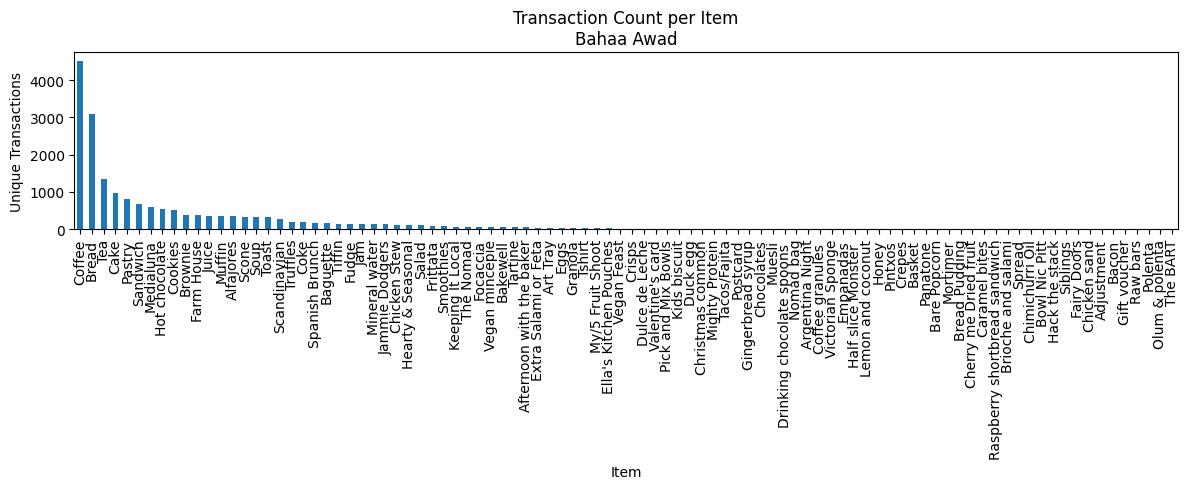

In [15]:
import matplotlib.pyplot as plt

# Bar plot of transaction counts per item
subtitle = "Bahaa Awad"

item_counts = (
    bread.groupby('item')['transaction']
    .nunique()
    .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\n{subtitle}")
plt.xlabel("Item")
plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

The bar plot shows that items such as Coffee and Bread appear in the highest number of unique transactions, indicating they are the most frequently purchased items in the dataset.

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [16]:
items_of_interest = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

bread[bread['item'].isin(items_of_interest)] \
    .groupby('item')['transaction'] \
    .nunique() \
    .sort_values(ascending=False)

,transaction
item,
Coffee,4528
Tea,1350
Juice,365
Alfajores,344
Chicken Stew,123


Coffee appears in 4,528 unique transactions, Tea in 1,350, Juice in 365, Alfajores in 344, and Chicken Stew in 123 transactions. Coffee and Tea are clearly the most frequently purchased among these items, indicating they are staple products in customer baskets, while Chicken Stew appears much less often, suggesting it is a niche or less commonly purchased item.

## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [17]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

# build baskets: list of items per transaction
basket = (
    bread.groupby('transaction')['item']
    .apply(list)
    .tolist()
)

te = TransactionEncoder()
oht = pd.DataFrame(te.fit(basket).transform(basket), columns=te.columns_).astype(bool)

oht.shape

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(9465, 94)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
freq_fp = fpgrowth(oht, min_support=0.2, use_colnames=True)
freq_fp.sort_values('support', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
1,0.478394,(Coffee)
0,0.327205,(Bread)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Using FP-Growth with a minimum support of 0.2, only single-item itemsets such as {Coffee} and {Bread} were identified as frequent. This indicates that these items appear in more than 20% of all transactions and dominate overall purchasing behavior. The absence of multi-item combinations at this threshold suggests that co-purchased itemsets occur less frequently than the chosen support cutoff. Lowering the support threshold would reveal more multi-item patterns.

## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [19]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_fp, metric="confidence", min_threshold=0.3)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']] \
    .sort_values(['confidence', 'lift'], ascending=False).head(15)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Association rules were generated using FP-Growth with confidence as the evaluation metric and a minimum confidence threshold of 0.3. This threshold was selected to balance rule quality and coverage, ensuring that extracted rules represent meaningful co-purchasing patterns while avoiding overly rare or noisy associations. The report table includes antecedents, consequents, support, confidence, and lift to evaluate both the strength and usefulness of the rules.

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (The rule {Coffee, Cake} ⇒ {Bread} means that a certain fraction of all transactions include coffee, cake, and bread together (this is reflected by the support value). Among customers who purchase both coffee and cake in the same transaction, the confidence indicates the proportion of those transactions that also include bread. A lift value greater than 1 suggests a positive association, meaning bread is purchased more often with coffee and cake than would be expected by chance. In practical terms, this implies that customers buying coffee and cake are more likely to also buy bread, which could inform product placement or bundled promotions in a bakery or café setting.)

>